# Estabilidad temporal: ¿el modelo se mantiene año con año?

## Qué responde este notebook

La etapa 4 eligió un modelo por resultado con una sola partición: entrenamiento 2016-2021,
validación 2022-2023 y prueba 2024-2025. Eso basta para elegir, pero no dice si el desempeño es
estable o si dependió de esa partición. Aquí se evalúa el mismo modelo sobre cinco cortes de tiempo
(*walk-forward* con ventana expandida): para cada año de 2021 a 2025, se entrena con todo lo anterior
y se prueba en ese año.

Dos precisiones para leer los resultados:

- La configuración es la misma en los cinco años: no se re-optimiza en cada uno, para que la
  comparación sea sobre el mismo modelo.
- Los años 2022 y 2023 se usaron para elegir el modelo, así que sus cortes no son una prueba
  independiente. Los de 2024 y 2025 sí lo son. El de 2021 tampoco se miró al elegir: en la
  partición de la etapa 4 era parte del entrenamiento, no de la evaluación.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
train_mask, val_mask, test_mask = experimentos.dividir_temporal(wr, range(2016, 2022), [2022, 2023], [2024, 2025])
X = wr[features_arbol]

## 1. El modelo elegido de cada resultado

La configuración que dejó [`4.4_ajuste_hiperparametros.ipynb`](4.4_ajuste_hiperparametros.ipynb):
XGBoost con error cuadrático para recepciones y yardas, y XGBoost con objetivo Poisson para
touchdowns.

In [2]:
CONFIG_ELEGIDA = {
    "receptions": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_yards": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_tds": dict(objective="count:poisson", max_depth=3, n_estimators=400, learning_rate=0.03),
}

def nuevo_modelo(target):
    return XGBRegressor(**CONFIG_ELEGIDA[target], random_state=0, n_jobs=-1)

## 2. Walk-forward: un corte por año, de 2021 a 2025

En cada corte, el R² y el D² fuera de muestra se miden contra la media del entrenamiento de ese
corte, como en [`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb). Se agregan la
correlación de Spearman semanal (qué tan bien ordena a los receptores de una misma semana) y el
sesgo: el del modelo y el que tendría predecir la media de entrenamiento, que refleja el cambio de
nivel de ese año.

In [3]:
filas = []
metricas_por_anio = {target: {} for target in modeling.TARGETS}
for target in modeling.TARGETS:
    y = wr[target]
    for anio, train_fold, test_fold in experimentos.folds_walk_forward(wr, [2021, 2022, 2023, 2024, 2025]):
        modelo = nuevo_modelo(target).fit(X[train_fold], y[train_fold])
        pred = pd.Series(modeling.clip_no_negativo(modelo.predict(X[test_fold])), index=wr.index[test_fold])
        m = modeling.metricas_target(target, y[test_fold], pred, y[train_fold].mean())
        metricas_por_anio[target][anio] = m
        filas.append({
            "target": target, "anio": anio, "n_train": int(train_fold.sum()), "n_prueba": int(test_fold.sum()),
            "metrica_principal": modeling.METRICA_PRINCIPAL[target],
            "valor_principal": m[modeling.METRICA_PRINCIPAL[target]],
            "r2_oos": m["r2_oos"], "d2_oos": m.get("d2_oos", np.nan),
            "pendiente": m["pendiente_calibracion"], "sesgo": m["sesgo"],
            "sesgo_media_entrenamiento": m["sesgo_media_entrenamiento"],
            "spearman_semanal": experimentos.spearman_semanal(wr[test_fold], y[test_fold], pred),
        })

tabla_estabilidad = pd.DataFrame(filas)
for target in modeling.TARGETS:
    print(f"--- {target}")
    print(tabla_estabilidad[tabla_estabilidad["target"] == target].drop(columns=["target", "metrica_principal"])
          .set_index("anio").to_string(float_format=lambda x: f"{x:.4f}"))
    print()

--- receptions
      n_train  n_prueba  valor_principal  r2_oos  d2_oos  pendiente  sesgo  sesgo_media_entrenamiento  spearman_semanal
anio                                                                                                                   
2021    11312      2483           1.9209  0.4385  0.4280     1.0415 0.0445                     0.0526            0.6889
2022    13795      2387           1.9576  0.4292  0.4226     1.0575 0.0600                     0.0388            0.6738
2023    16182      2476           1.8974  0.4484  0.4395     1.0361 0.1113                     0.1020            0.6848
2024    18658      2441           1.9004  0.4463  0.4447     1.0621 0.0443                     0.0840            0.7011
2025    21099      2511           1.7438  0.4735  0.4602     0.9713 0.0236                     0.3555            0.6978

--- receiving_yards
      n_train  n_prueba  valor_principal  r2_oos  d2_oos  pendiente  sesgo  sesgo_media_entrenamiento  spearman_semanal
anio

**Lectura.** Los tres modelos se sostienen en los cinco años:

| Resultado | Métrica principal | R² fuera de muestra | Pendiente | Spearman semanal |
|---|---|---|---|---|
| `receptions` | RMSE 1.7438-1.9576 | 0.4292-0.4735 | 0.9713-1.0621 | 0.6738-0.7011 |
| `receiving_yards` | RMSE 27.0613-29.6111 | 0.3555-0.3863 | 0.9709-1.0777 | 0.6306-0.6606 |
| `receiving_tds` | deviance 0.5914-0.6491 | 0.0835-0.0973 (D² 0.1178-0.1480) | 0.9944-1.1341 | 0.2748-0.3050 |

No hay deterioro con el tiempo: en R² fuera de muestra, 2025, que no se usó para elegir nada, es el
mejor año en los tres resultados; 2024 queda tercero en recepciones y yardas y cuarto en touchdowns.
Las pendientes de calibración quedan dentro de 0.9-1.1 salvo una: touchdowns en 2024 (1.134): una
pendiente mayor a 1 quiere decir que ese año sus predicciones quedaron demasiado parejas entre
receptores.

Las columnas de sesgo muestran un punto importante. En 2025, predecir la media de entrenamiento se
habría pasado por 0.36 recepciones y 4.6 yardas por receptor, porque ese año la producción por fila
bajó; el modelo se pasó solo por 0.02 y 0.53. Las variables rezagadas siguen el cambio de nivel, que
es lo que se espera de ellas.

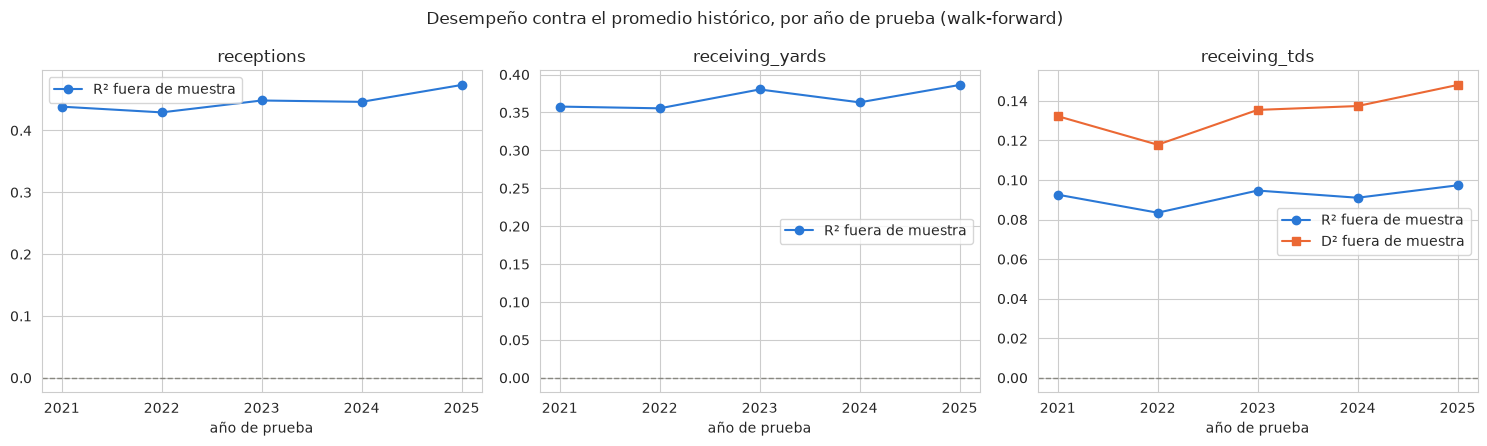

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, modeling.TARGETS):
    datos = tabla_estabilidad[tabla_estabilidad["target"] == target]
    ax.plot(datos["anio"], datos["r2_oos"], marker="o", color=AZUL, label="R² fuera de muestra")
    if target == "receiving_tds":
        ax.plot(datos["anio"], datos["d2_oos"], marker="s", color=NARANJA, label="D² fuera de muestra")
    ax.axhline(0, color=GRIS, linewidth=1, linestyle="--")
    ax.set_title(target)
    ax.set_xlabel("año de prueba")
    ax.set_xticks(datos["anio"])
    ax.legend()
fig.suptitle("Desempeño contra el promedio histórico, por año de prueba (walk-forward)")
plt.tight_layout()
plt.show()

## 3. Requisitos del modelo, con los cinco años

Los requisitos de 4.1 piden R² fuera de muestra mayor a 0 (y D² en touchdowns) en validación y en
cada año del walk-forward, sesgo adicional al de la media de entrenamiento de a lo más 5% y pendiente
de calibración entre 0.9 y 1.1 en validación. Aquí se revisan todos juntos.

In [5]:
filas_requisitos = {}
for target in modeling.TARGETS:
    y = wr[target]
    modelo = nuevo_modelo(target).fit(X[train_mask], y[train_mask])
    m_val = modeling.metricas_target(target, y[val_mask], modeling.clip_no_negativo(modelo.predict(X[val_mask])), y[train_mask].mean())
    cumple, detalle = experimentos.cumple_requisitos(target, m_val, metricas_por_anio[target])
    filas_requisitos[target] = {**detalle, "cumple todos": cumple}
tabla_requisitos = pd.DataFrame(filas_requisitos).fillna("no aplica")
tabla_requisitos.loc[[r for r in tabla_requisitos.index if r != "cumple todos"] + ["cumple todos"]]

,receptions,receiving_yards,receiving_tds
R2 fuera de muestra > 0 (validacion),True,True,True
sesgo adicional al de la media de entrenamiento <= 5% de la media (validacion),True,True,True
pendiente de calibracion entre 0.9 y 1.1 (validacion),True,True,True
R2 fuera de muestra > 0 en cada anio,True,True,True
D2 fuera de muestra > 0 (validacion),no aplica,no aplica,True
D2 fuera de muestra > 0 en cada anio,no aplica,no aplica,True
cumple todos,True,True,True


**Lectura.** Los tres modelos cumplen todos los requisitos de 4.1 con los cinco años incluidos. El
requisito de pendiente se revisa en validación; por año, solo touchdowns en 2024 sale del rango
0.9-1.1 (1.134), y las demás van de 0.971 a 1.078.

## 4. ¿Qué tan parejo es el desempeño entre años?

El coeficiente de variación (desviación estándar entre media) de la métrica principal resume qué
tanto cambia de un año a otro. Como la métrica principal también depende de qué tan variable fue
cada temporada, se acompaña del rango del R² fuera de muestra, que ya descuenta esa dificultad.

In [6]:
resumen = tabla_estabilidad.groupby("target").agg(
    metrica_principal=("metrica_principal", "first"),
    media=("valor_principal", "mean"), desviacion=("valor_principal", "std"),
    r2_oos_minimo=("r2_oos", "min"), r2_oos_maximo=("r2_oos", "max"),
    spearman_minimo=("spearman_semanal", "min"), spearman_maximo=("spearman_semanal", "max"),
)
resumen["coef_variacion"] = resumen["desviacion"] / resumen["media"]
resumen.loc[list(modeling.TARGETS)].round(4)

,metrica_principal,media,desviacion,r2_oos_minimo,r2_oos_maximo,spearman_minimo,spearman_maximo,coef_variacion
target,,,,,,,,
receptions,rmse,1.8840,0.0820,0.4292,0.4735,0.6738,0.7011,0.0435
receiving_yards,rmse,28.7109,0.9811,0.3555,0.3863,0.6306,0.6606,0.0342
receiving_tds,deviance_poisson,0.6213,0.0234,0.0835,0.0973,0.2748,0.3050,0.0377


**Lectura.** El coeficiente de variación de la métrica principal es de 0.0435 en recepciones, 0.0342 en
yardas y 0.0377 en touchdowns, y el R² fuera de muestra se mueve en rangos estrechos (0.43-0.47,
0.36-0.39 y 0.0835-0.0973). El desempeño cambia poco según el año que toque de prueba.

## 5. ¿Cambia dentro de la temporada?

Otro corte: sobre la prueba (2024-2025), con el modelo entrenado en 2016-2021, se separa por bloque
de semanas. En las semanas 1-4 los promedios de la temporada en curso salen de pocos partidos (y en la primera
aparición de cada receptor faltan); en las 14-18 ya se jugó casi toda la temporada.

In [7]:
prueba = wr[test_mask].copy()
prueba["bloque_semanas"] = pd.cut(prueba["week"], bins=[0, 4, 9, 13, 18], labels=["1-4", "5-9", "10-13", "14-18"])

filas_bloque = []
for target in modeling.TARGETS:
    y = wr[target]
    modelo = nuevo_modelo(target).fit(X[train_mask], y[train_mask])
    prueba[f"pred_{target}"] = modeling.clip_no_negativo(modelo.predict(X[test_mask]))
    for bloque, grupo in prueba.groupby("bloque_semanas", observed=True):
        m = modeling.metricas_target(target, grupo[target], grupo[f"pred_{target}"], y[train_mask].mean())
        filas_bloque.append({"target": target, "bloque_semanas": bloque, "n": len(grupo),
                             "valor_principal": m[modeling.METRICA_PRINCIPAL[target]], "r2_oos": m["r2_oos"],
                             "sesgo": m["sesgo"]})

tabla_bloque = pd.DataFrame(filas_bloque)
tabla_bloque.pivot(index="bloque_semanas", columns="target", values=["valor_principal", "r2_oos", "sesgo"]).reindex(["1-4", "5-9", "10-13", "14-18"]).round(4)

valor_principal                                   r2_oos                                    sesgo                           
target           receiving_tds receiving_yards receptions receiving_tds receiving_yards receptions receiving_tds receiving_yards receptions
bloque_semanas                                                                                                                             
1-4                     0.6220         26.9932     1.8668        0.0739          0.3715     0.4275        0.0038          2.6706     0.1036
5-9                     0.6232         28.0980     1.8429        0.0945          0.3711     0.4486       -0.0064          0.3195     0.0235
10-13                   0.6005         29.0067     1.7878        0.0898          0.3430     0.4461        0.0048          1.6180     0.1332
14-18                   0.6375         27.7305     1.8377        0.1027          0.4030     0.4804       -0.0163          0.5783    -0.0051

**Lectura.** No hay un patrón de mejora conforme avanza la temporada. Las semanas 14-18 tienen el R²
más alto en los tres resultados (0.480, 0.403 y 0.103), pero el resto no sigue un orden: en yardas,
el bloque 10-13 es el más bajo (0.343). En yardas, las semanas 1-4 tienen el sesgo más alto (+2.67);
una explicación posible, que aquí no se prueba, es que al inicio de temporada, con pocos partidos de
la temporada en curso, pesan más los promedios de carrera. En recepciones el sesgo es positivo en
tres de los cuatro bloques, mayor en 1-4 y 10-13 (+0.104 y +0.133), y casi nulo en 14-18 (−0.005).
Son dos temporadas de prueba, así que estas diferencias entre bloques son indicios, no conclusiones.

## Cierre

El modelo elegido de cada resultado es estable año con año: R² fuera de muestra entre 0.43 y 0.47 en
recepciones, entre 0.36 y 0.39 en yardas y entre 0.0835 y 0.0973 en touchdowns, coeficiente de
variación de 0.0342 a 0.0435 en la métrica principal, y 2025, que no se usó para elegir, es el mejor
año en R² fuera de muestra. Los tres cumplen los requisitos de 4.1 en validación y en cada año.

Dos puntos a vigilar en el flujo semanal: la pendiente de touchdowns, la que más varía entre años
(de 0.994 a 1.134, fuera del rango en 2024), y el inicio de temporada, donde en la prueba las yardas
se sobreestimaron (+2.67 por receptor en las semanas 1-4).
[`6.1_modelo_final_y_temporada_actual.ipynb`](6.1_modelo_final_y_temporada_actual.ipynb) revisa las
semanas de 2026 ya jugadas.

Anterior: [`4.9_ventana_entrenamiento.ipynb`](4.9_ventana_entrenamiento.ipynb) · Siguiente:
[`5.2_benchmark_vs_legado.ipynb`](5.2_benchmark_vs_legado.ipynb)